In [1]:
import numpy as np
import matplotlib.pyplot as  plt

In [2]:
def correctFunction(x):
    return 15 + 2.4*x - 0.5*x**2 - 0.35*x**3

In [3]:
npoints = 21
x_list = np.linspace(-5, 5, npoints)
data0 = np.array([x_list, correctFunction(x_list)])

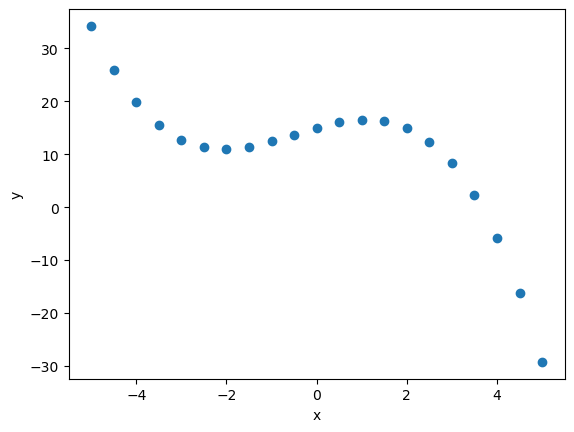

In [4]:
plt.xlabel('x')
plt.ylabel('y')
plt.scatter(data0[0], data0[1])

In [5]:
0.1 * (2*np.random.rand(npoints) - 1)

array([ 0.06675193,  0.02321381, -0.08359414,  0.0526285 , -0.07947918,
       -0.03201605, -0.01347863, -0.05640699, -0.02574859, -0.03212216,
        0.00995837,  0.06959966,  0.03974251, -0.00109974,  0.07052549,
       -0.0002293 , -0.08608082,  0.03721241,  0.03345192, -0.00756182,
        0.02168441])

In [6]:
data = np.array([data0[0] + 0.25 * (2*np.random.rand(npoints) - 1), data0[1] + 5.0 * (2*np.random.rand(npoints)-1)])

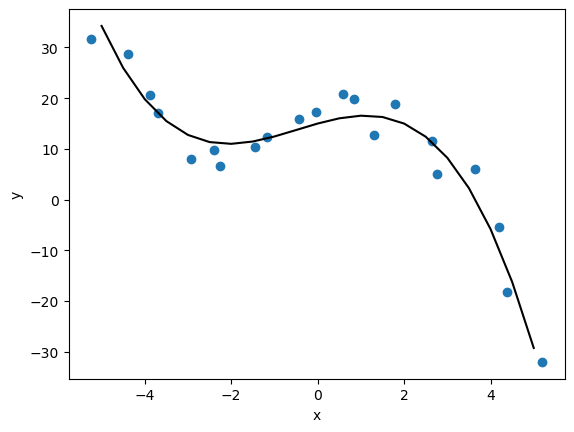

In [7]:
plt.xlabel('x')
plt.ylabel('y')

plt.plot(data0[0], data0[1], 'black')
plt.scatter(data[0], data[1])

In [8]:
def polynomialModel(x, a):
    t = 0
    for k in range(len(a)):
        t = t + a[k] * x**k
    return t

In [9]:
a0 = np.array([15, 2.4, -0.5, -0.35])
#a0 = np.array([1, 1, 1, 1])

In [10]:
npoints = 21

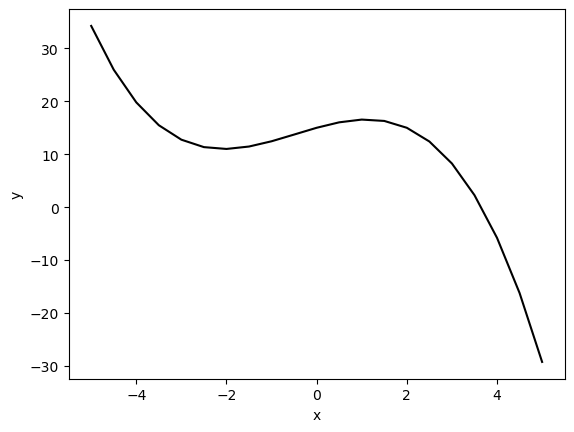

In [11]:
plt.xlabel('x')
plt.ylabel('y')

x_list = np.linspace(-5, 5, npoints)
plt.plot(x_list, polynomialModel(x_list, a0), 'black')

In [12]:
def errorFit(f, coefficients, data):
    # f: The fit function
    # coefficients: ai that we try to optimize
    # data: The data we try to fit
    error = 0
    for i in range(len(data[0])):
        error = error + (data[1, i] - f(data[0, i], coefficients))**2
        #print(error)
    return error

In [13]:
errorFit(polynomialModel, a0, data)

np.float64(303.96076124981136)

In [14]:
def errorFitGradient(f, coefficients, data):
    # f: The fit function
    # coefficients: ai that we try to optimize
    # data: The data we try to fit
    return -2 * np.array([
            np.sum(np.array([(data[1, i] - f(data[0, i], coefficients)) * data[0, i]**k for i in range(len(data[0]))])) 
        for k in range(len(coefficients))])

In [15]:
errorFitGradient(polynomialModel, a0, data)

array([   -5.79274882,  -132.63434939,    93.22039429, -2606.2179194 ])

In [16]:
iterations = 100000
h = 0.000000001
a = 2*np.random.rand(6) - 1

print(a)

for i in range(iterations):
    a = a - h * errorFitGradient(polynomialModel, a, data)

print(a)

[ 0.64315888 -0.17088751 -0.3728161  -0.73346121  0.26048314  0.59804699]
[ 0.68068928 -0.11955365 -0.26289344 -0.40179777  0.0195512   0.00768268]


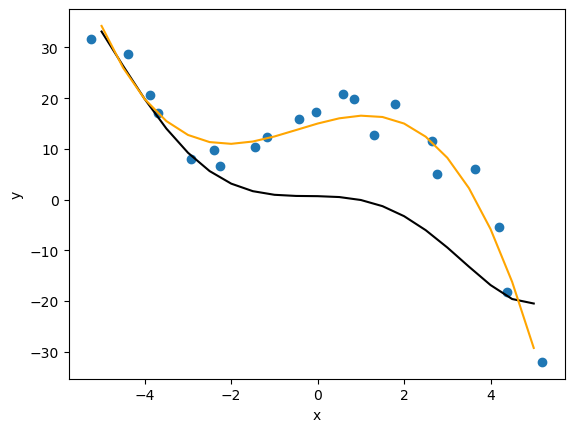

In [17]:
plt.xlabel('x')
plt.ylabel('y')

x_list = np.linspace(-5, 5, npoints)
plt.plot(x_list, polynomialModel(x_list, a), 'black')
plt.plot(x_list, polynomialModel(x_list, a0), 'orange')
plt.scatter(data[0], data[1])

In [18]:
print(errorFit(polynomialModel, a, data))
print(errorFit(polynomialModel, a0, data))

3451.6483090869515
303.96076124981136


In [19]:
print(a)
print(a0)

[ 0.68068928 -0.11955365 -0.26289344 -0.40179777  0.0195512   0.00768268]
[15.    2.4  -0.5  -0.35]
